In [ ]:
!pip install gymnasium

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [ ]:
import torch.nn.functional as F

class ActorCriticDeepFeatureLSTM(nn.Module):
    def __init__(self, observation_space, action_space, hidden_size=128, num_layers=1):
        super(ActorCriticDeepFeatureLSTM, self).__init__()

        self.input_size = 3
        self.action_size = action_space.n
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Feature Extraction (Feed-forward)
        self.feature_extractor = nn.Sequential(
            nn.Linear(self.input_size, hidden_size),
            nn.ReLU()
        )

        # Temporal Processing (RNN)
        # Note: input_size is now hidden_size because of the extractor
        self.lstm = nn.LSTM(input_size=self.hidden_size,
                            hidden_size=self.hidden_size,
                            num_layers=self.num_layers,
                            batch_first=True)

        # Final Policy/Value heads (Feed-forward)
        self.actor_head = nn.Linear(self.hidden_size, self.action_size)
        self.critic_head = nn.Linear(self.hidden_size, 1)

    def forward(self, x, hidden_state=None):
        # x shape: (batch, seq_len, input_size)

        # Apply feature extractor to every time step
        # We use a view to process all time steps at once, then reshape back
        batch_size, seq_len, _ = x.size()
        flat_x = x.reshape(-1, self.input_size)
        features = self.feature_extractor(flat_x)
        features = features.reshape(batch_size, seq_len, self.hidden_size)

        # Pass extracted features to LSTM
        lstm_out, new_hidden_state = self.lstm(features, hidden_state)
        last_step = lstm_out[:, -1, :]

        # Final heads
        actor_logits = self.actor_head(last_step)
        critic_value = self.critic_head(last_step)

        return actor_logits, critic_value, new_hidden_state

In [ ]:
import torch.distributions as distributions

def calculate_returns(rewards, gamma):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.insert(0, R)
    return torch.tensor(returns, dtype=torch.float32)

def preprocess_obs(obs):
    # obs is (player_sum, dealer_card, usable_ace)
    # Convert to a tensor of shape (1, 1, 3)
    res = torch.tensor([obs[0], obs[1], float(obs[2])], dtype=torch.float32)
    return res.view(1, 1, 3)

def train_actor_critic_blackjack(model, optimizer, env, num_episodes, gamma=0.99):
    for episode in range(num_episodes):
        obs, _ = env.reset()
        hidden_state = None

        log_probs, values, rewards = [], [], []
        done, truncated = False, False
        episode_reward = 0

        while not (done or truncated):
            # Preprocess the Tuple into a Vector
            obs_tensor = preprocess_obs(obs).to(device)

            # Model Inference
            logits, val, hidden_state = model(obs_tensor, hidden_state)

            # Action Selection
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()

            next_obs, reward, done, truncated, _ = env.step(action.item())

            # Store for training
            log_probs.append(dist.log_prob(action))
            values.append(val)
            rewards.append(reward)

            obs = next_obs
            episode_reward += reward

        # --- Optimization Step (After Episode) ---
        if len(rewards) == 0: continue # Safety check

        returns = calculate_returns(rewards, gamma).to(device)
        values_tensor = torch.cat(values).view(-1)

        advantages = returns - values_tensor.detach()

        actor_loss = -(torch.stack(log_probs) * advantages).mean()
        critic_loss = F.mse_loss(values_tensor, returns)
        total_loss = actor_loss + critic_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        if episode % 1000 == 0:
            print(f"Episode {episode} | Reward: {episode_reward} | Loss: {total_loss.item():.4f}")

print("Training function 'train_actor_critic' defined.")

Training function 'train_actor_critic' defined.


In [ ]:
import gymnasium as gym

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
env = gym.make("Blackjack-v1", sab=True) # 'sab' follows Sutton and Barto rules

model = ActorCriticDeepFeatureLSTM(env.observation_space, env.action_space).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # Smaller LR for stability

# Run
train_actor_critic_blackjack(model, optimizer, env, num_episodes=25000)

Episode 0 | Reward: 1.0 | Loss: 1.1236
Episode 1000 | Reward: -1.0 | Loss: 0.2903
Episode 2000 | Reward: 1.0 | Loss: 0.7503
Episode 3000 | Reward: -1.0 | Loss: 0.6983
Episode 4000 | Reward: -1.0 | Loss: 0.5953
Episode 5000 | Reward: -1.0 | Loss: 1.1523
Episode 6000 | Reward: -1.0 | Loss: 0.1596
Episode 7000 | Reward: -1.0 | Loss: 0.2007
Episode 8000 | Reward: -1.0 | Loss: 0.7162
Episode 9000 | Reward: 1.0 | Loss: 0.5841
Episode 10000 | Reward: -1.0 | Loss: 1.1662
Episode 11000 | Reward: -1.0 | Loss: 1.2555
Episode 12000 | Reward: 1.0 | Loss: 2.4545
Episode 13000 | Reward: -1.0 | Loss: 0.3985
Episode 14000 | Reward: -1.0 | Loss: 0.1506
Episode 15000 | Reward: -1.0 | Loss: 0.6407
Episode 16000 | Reward: 1.0 | Loss: 0.8977
Episode 17000 | Reward: -1.0 | Loss: 0.0283
Episode 18000 | Reward: 1.0 | Loss: 0.5202
Episode 19000 | Reward: 1.0 | Loss: 0.3350
Episode 20000 | Reward: -1.0 | Loss: 0.2682
Episode 21000 | Reward: -1.0 | Loss: 0.2001
Episode 22000 | Reward: 1.0 | Loss: 0.2935
Episode 2

In [ ]:
import numpy as np
import torch

def evaluate_agent(model, env, num_test_episodes, device):
    model.eval()  # Set to evaluation mode
    total_rewards = []
    wins = 0

    with torch.no_grad(): # Disable gradient calculation for efficiency
        for episode in range(num_test_episodes):
            observation, _ = env.reset()
            hidden_state = None # Reset memory for a new hand
            episode_reward = 0
            done = False
            truncated = False

            while not (done or truncated):
                # Preprocess the Tuple observation into a (1, 1, 3) tensor
                # Reuse the preprocess_obs function from the training step
                observation_tensor = preprocess_obs(observation).to(device)

                # Pass hidden_state and get the new one back
                actor_logits, _, hidden_state = model(observation_tensor, hidden_state)

                # Choose action greedily (highest probability)
                # actor_logits shape is (1, action_size), so argmax over dim 1
                action = torch.argmax(actor_logits, dim=1).item()

                observation, reward, done, truncated, _ = env.step(action)
                episode_reward += reward

            total_rewards.append(episode_reward)
            if episode_reward > 0:
                wins += 1

    avg_reward = np.mean(total_rewards)
    win_rate = wins / num_test_episodes

    print(f"\nEvaluation complete over {num_test_episodes} episodes:")
    print(f"Average Reward: {avg_reward:.4f}")
    print(f"Win Rate: {win_rate * 100:.2f}%")
    return avg_reward, win_rate

In [ ]:
num_test_episodes = 1000
# Pass 'device' which you defined earlier (e.g., device = torch.device("cuda" or "cpu"))
avg_reward, win_rate = evaluate_agent(model, env, num_test_episodes, device)

print(f"Agent evaluated with {num_test_episodes} episodes.")
print(f"Average reward over test episodes: {avg_reward:.4f}")
print(f"Win rate over test episodes: {win_rate:.4f}")


Evaluation complete over 1000 episodes:
Average Reward: -0.1970
Win Rate: 37.70%
Agent evaluated with 1000 episodes.
Average reward over test episodes: -0.1970
Win rate over test episodes: 0.3770


In [ ]:
def train_with_config(env, lr, num_episodes, gamma, hidden_size, num_layers, device):
    # Pass hidden_size and num_layers to the model
    model = ActorCriticDeepFeatureLSTM(env.observation_space,
                            env.action_space,
                            hidden_size=hidden_size,
                            num_layers=num_layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    episode_rewards = []

    for episode in range(num_episodes):
        obs, _ = env.reset()
        hidden_state = None
        log_probs, values, rewards = [], [], []
        done, truncated = False, False
        ep_reward = 0

        while not (done or truncated):
            obs_tensor = preprocess_obs(obs).to(device)
            logits, val, hidden_state = model(obs_tensor, hidden_state)

            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()

            next_obs, reward, done, truncated, _ = env.step(action.item())

            log_probs.append(dist.log_prob(action))
            values.append(val)
            rewards.append(reward)

            obs = next_obs
            ep_reward += reward

        # Standard Update Logic
        if len(rewards) > 0:
            returns = calculate_returns(rewards, gamma).to(device)
            values_tensor = torch.cat(values).view(-1)
            advantages = returns - values_tensor.detach()

            actor_loss = -(torch.stack(log_probs) * advantages).mean()
            critic_loss = F.mse_loss(values_tensor, returns)

            optimizer.zero_grad()
            (actor_loss + critic_loss).backward()
            optimizer.step()

        episode_rewards.append(ep_reward)

    return model, episode_rewards

In [ ]:
# Experiment Configurations
configs = [
    {
        "name": "Shallow (1 Layer) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Deep (2 Layers) gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 128, "layers": 2
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 128 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.95,
        "hidden": 128, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 256 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 256, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers",
        "lr": 0.0005, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },
    {
        "name": "Shallow (1 Layers) with gamma 0.99 and 512 hidden layers and greater learning rate",
        "lr": 0.001, "episodes": 10000, "gamma": 0.99,
        "hidden": 512, "layers": 1
    },

]

results = {}

for cfg in configs:
    print(f"Testing {cfg['name']}...")
    model, rewards = train_with_config(
        env, cfg['lr'], cfg['episodes'], cfg['gamma'],
        cfg['hidden'], cfg['layers'], device
    )

    avg_r, win_r = evaluate_agent(model, env, 1000, device)
    results[cfg['name']] = {"rewards": rewards, "win_rate": win_r}

# Use the compare_results function from before to plot!

Testing Shallow (1 Layer) gamma 0.99 and 128 hidden layers...

Evaluation complete over 1000 episodes:
Average Reward: -0.2150
Win Rate: 36.80%
Testing Deep (2 Layers) gamma 0.99 and 128 hidden layers...

Evaluation complete over 1000 episodes:
Average Reward: -0.1050
Win Rate: 42.00%
Testing Shallow (1 Layers) with gamma 0.99 and 128 hidden layers...

Evaluation complete over 1000 episodes:
Average Reward: -0.1500
Win Rate: 39.70%
Testing Shallow (1 Layers) with gamma 0.99 and 256 hidden layers...

Evaluation complete over 1000 episodes:
Average Reward: -0.1630
Win Rate: 39.70%
Testing Shallow (1 Layers) with gamma 0.99 and 512 hidden layers...

Evaluation complete over 1000 episodes:
Average Reward: -0.1850
Win Rate: 38.90%
Testing Shallow (1 Layers) with gamma 0.99 and 512 hidden layers and greater learning rate...

Evaluation complete over 1000 episodes:
Average Reward: -0.1750
Win Rate: 38.80%


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 15.4 MB/s eta 0:00:00


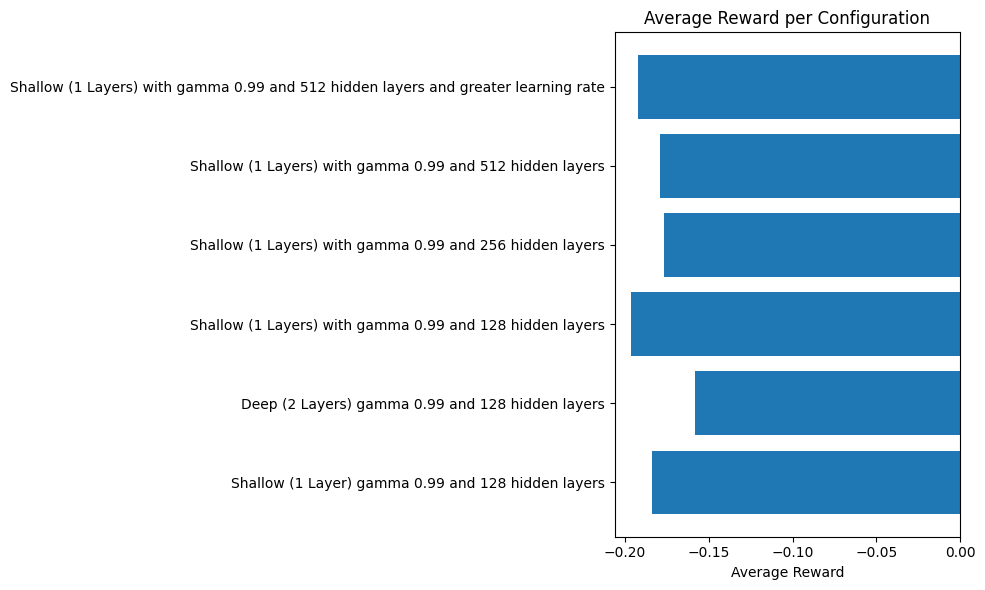

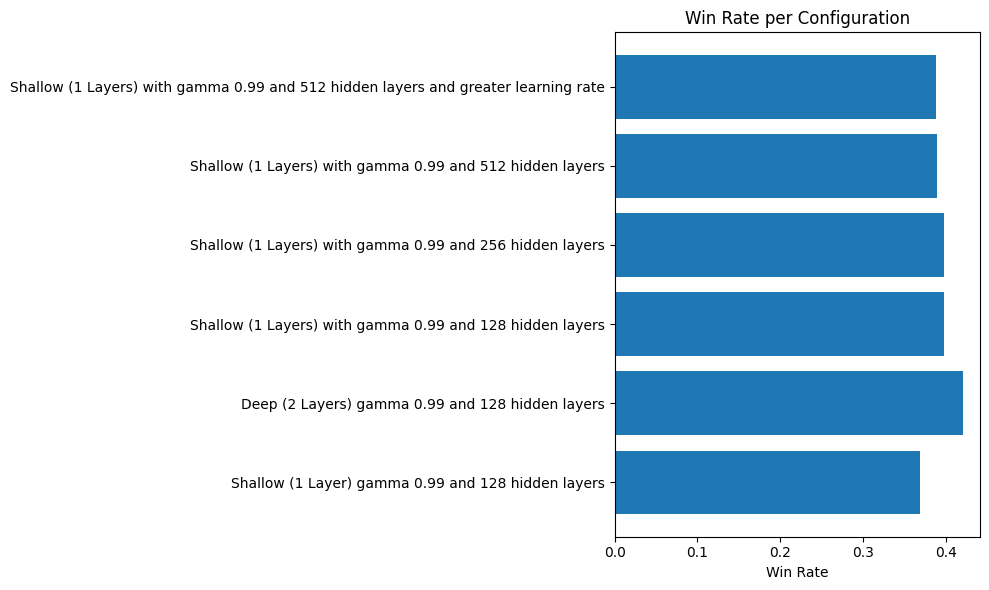

In [ ]:
import matplotlib.pyplot as plt

# Convert results dict into a list of dicts
results_list = [
    {
        "name": name,
        "avg_reward": sum(data["rewards"]) / len(data["rewards"]),
        "win_rate": data["win_rate"]
    }
    for name, data in results.items()
]

# Extract fields
names = [r["name"] for r in results_list]
avg_rewards = [r["avg_reward"] for r in results_list]
win_rates = [r["win_rate"] for r in results_list]

# --- Average Reward ---
plt.figure(figsize=(10, 6))
plt.barh(names, avg_rewards)
plt.xlabel("Average Reward")
plt.title("Average Reward per Configuration")
plt.tight_layout()
plt.show()

# --- Win Rate ---
plt.figure(figsize=(10, 6))
plt.barh(names, win_rates)
plt.xlabel("Win Rate")
plt.title("Win Rate per Configuration")
plt.tight_layout()
plt.show()


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00


In [ ]:
import optuna

def objective(trial):
    # 1. Define the search space
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    hidden_size = trial.suggest_categorical("hidden_size", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    gamma = trial.suggest_float("gamma", 0.9, 0.999)
    num_episodes = 15000 # Fixed for fair comparison

    # 2. Train the model with these parameters
    # Using the train_with_config function we built earlier
    model, _ = train_with_config(
        env,
        lr=lr,
        num_episodes=num_episodes,
        gamma=gamma,
        hidden_size=hidden_size,
        num_layers=num_layers,
        device=device
    )

    # 3. Evaluate the model
    # We use a larger test set (2000) to reduce 'luck' in the score
    avg_reward, win_rate = evaluate_agent(model, env, num_test_episodes=2000, device=device)

    # Optuna tries to MAXIMIZE this value
    return win_rate

In [ ]:
# Create a study object and specify the direction is 'maximize'.
study = optuna.create_study(direction="maximize")

# Run 30 different trials (experiments)
study.optimize(objective, n_trials=30)

print("Optimization finished!")
print("Best trial:")
trial = study.best_trial

print(f"  Value (Win Rate): {trial.value:.4f}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-01-20 19:29:48,361] A new study created in memory with name: no-name-42b1d401-96a4-4b73-90a5-d20638023580
[I 2026-01-20 19:31:10,158] Trial 0 finished with value: 0.386 and parameters: {'lr': 0.00018313770510443197, 'hidden_size': 128, 'num_layers': 1, 'gamma': 0.9019405545291659}. Best is trial 0 with value: 0.386.



Evaluation complete over 2000 episodes:
Average Reward: -0.1825
Win Rate: 38.60%


[I 2026-01-20 20:09:50,718] Trial 1 finished with value: 0.4025 and parameters: {'lr': 0.008557357479409758, 'hidden_size': 512, 'num_layers': 2, 'gamma': 0.992490764111154}. Best is trial 1 with value: 0.4025.



Evaluation complete over 2000 episodes:
Average Reward: -0.1420
Win Rate: 40.25%


[I 2026-01-20 20:17:17,999] Trial 2 finished with value: 0.3775 and parameters: {'lr': 0.0060208967504930795, 'hidden_size': 256, 'num_layers': 2, 'gamma': 0.9754162541281788}. Best is trial 1 with value: 0.4025.


...


Evaluation complete over 2000 episodes:
Average Reward: -0.1435
Win Rate: 39.75%


[I 2026-01-20 22:44:18,287] Trial 28 finished with value: 0.3765 and parameters: {'lr': 0.0002208698035009419, 'hidden_size': 256, 'num_layers': 2, 'gamma': 0.9942409665946078}. Best is trial 6 with value: 0.4145.



Evaluation complete over 2000 episodes:
Average Reward: -0.2075
Win Rate: 37.65%


[I 2026-01-20 22:55:29,120] Trial 29 finished with value: 0.3825 and parameters: {'lr': 0.00016700378128517616, 'hidden_size': 512, 'num_layers': 1, 'gamma': 0.9765025817939817}. Best is trial 6 with value: 0.4145.



Evaluation complete over 2000 episodes:
Average Reward: -0.1875
Win Rate: 38.25%
Optimization finished!
Best trial:
  Value (Win Rate): 0.4145
  Params: 
    lr: 0.00019060026105396393
    hidden_size: 128
    num_layers: 3
    gamma: 0.9732911965207408


In [ ]:
def train_with_config(env, lr, num_episodes, gamma, hidden_size, num_layers, device):
    # Pass hidden_size and num_layers to the model
    model = ActorCriticDeepFeatureLSTM(env.observation_space,
                            env.action_space,
                            hidden_size=hidden_size,
                            num_layers=num_layers).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    episode_rewards = []

    for episode in range(num_episodes):
        obs, _ = env.reset()
        hidden_state = None
        log_probs, values, rewards = [], [], []
        done, truncated = False, False
        ep_reward = 0

        while not (done or truncated):
            obs_tensor = preprocess_obs(obs).to(device)
            logits, val, hidden_state = model(obs_tensor, hidden_state)

            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()

            next_obs, reward, done, truncated, _ = env.step(action.item())

            log_probs.append(dist.log_prob(action))
            values.append(val)
            rewards.append(reward)

            obs = next_obs
            ep_reward += reward

        # Standard Update Logic
        if len(rewards) > 0:
            returns = calculate_returns(rewards, gamma).to(device)
            values_tensor = torch.cat(values).view(-1)
            advantages = returns - values_tensor.detach()

            actor_loss = -(torch.stack(log_probs) * advantages).mean()
            critic_loss = F.mse_loss(values_tensor, returns)

            optimizer.zero_grad()
            (actor_loss + critic_loss).backward()
            optimizer.step()

        episode_rewards.append(ep_reward)

    return model, episode_rewards
trained_model, rewards_history = train_with_config(
    env,
    lr=0.00019060026105396393,
    num_episodes=50000,
    gamma=0.9134175173773155,
    hidden_size=128,
    num_layers=3,
    device=device
)

In [ ]:
def evaluate_agent(model, env, num_test_episodes=10000, device='cpu'):
    model.eval()  # Set model to evaluation mode
    wins = 0
    draws = 0
    losses = 0
    total_reward = 0

    with torch.no_grad(): # No gradient calculation needed for evaluation
        for _ in range(num_test_episodes):
            obs, _ = env.reset()
            hidden_state = None
            done, truncated = False, False

            while not (done or truncated):
                obs_tensor = preprocess_obs(obs).to(device)
                # Forward pass
                logits, _, hidden_state = model(obs_tensor, hidden_state)

                # Take the BEST action (Argmax) instead of sampling
                action = torch.argmax(logits, dim=1).item()

                obs, reward, done, truncated, _ = env.step(action)
                total_reward += reward

            if reward > 0:
                wins += 1
            elif reward == 0:
                draws += 1
            else:
                losses += 1

    win_rate = (wins / num_test_episodes) * 100
    avg_reward = total_reward / num_test_episodes

    print(f"--- Evaluation Results ({num_test_episodes} episodes) ---")
    print(f"Win Rate:    {win_rate:.2f}%")
    print(f"Draw Rate:   {(draws / num_test_episodes) * 100:.2f}%")
    print(f"Loss Rate:   {(losses / num_test_episodes) * 100:.2f}%")
    print(f"Avg Reward:  {avg_reward:.4f}")

    return avg_reward, win_rate

# Execute evaluation
avg_reward, win_rate = evaluate_agent(trained_model, env, device=device)

--- Evaluation Results (10000 episodes) ---
Win Rate:    42.04%
Draw Rate:   6.78%
Loss Rate:   51.18%
Avg Reward:  -0.0914


In [ ]:
import matplotlib.pyplot as plt

# Extract completed trials only
trials = [t for t in study.trials if t.value is not None]

win_rates = [t.value for t in trials]
lrs = [t.params["lr"] for t in trials]
gammas = [t.params["gamma"] for t in trials]
hidden_sizes = [t.params["hidden_size"] for t in trials]
num_layers = [t.params["num_layers"] for t in trials]

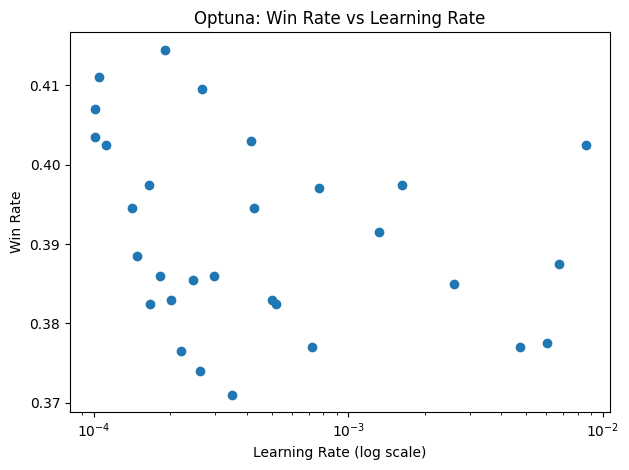

In [ ]:
plt.figure()
plt.scatter(lrs, win_rates)
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Learning Rate")
plt.tight_layout()
plt.show()


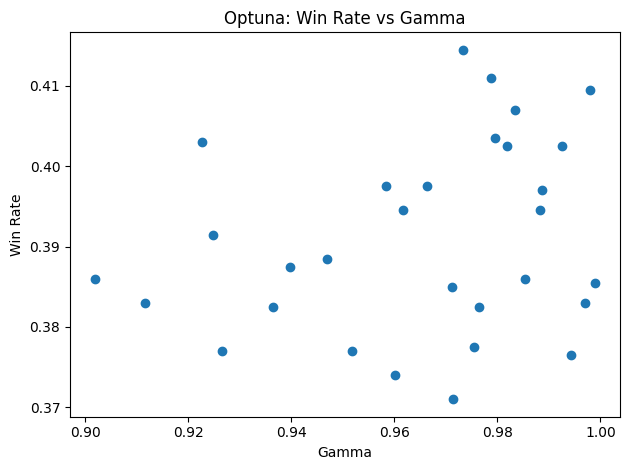

In [ ]:
plt.figure()
plt.scatter(gammas, win_rates)
plt.xlabel("Gamma")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Gamma")
plt.tight_layout()
plt.show()


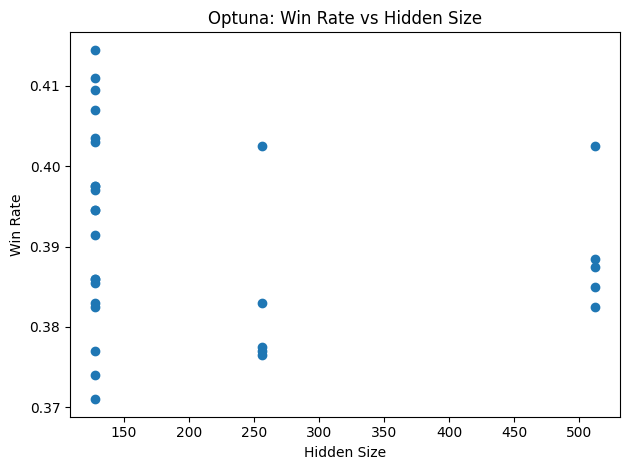

In [ ]:
plt.figure()
plt.scatter(hidden_sizes, win_rates)
plt.xlabel("Hidden Size")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Hidden Size")
plt.tight_layout()
plt.show()


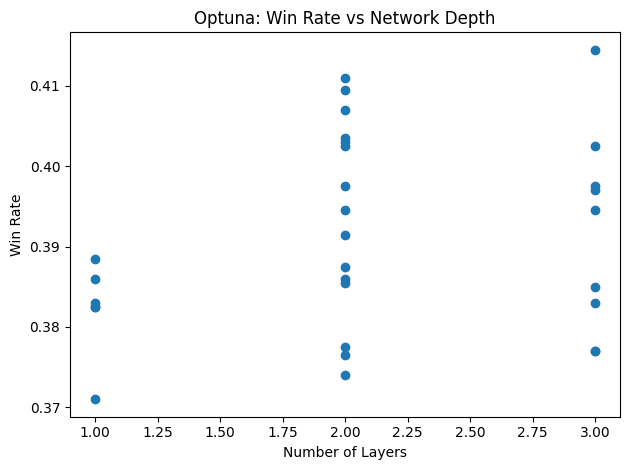

In [ ]:
plt.figure()
plt.scatter(num_layers, win_rates)
plt.xlabel("Number of Layers")
plt.ylabel("Win Rate")
plt.title("Optuna: Win Rate vs Network Depth")
plt.tight_layout()
plt.show()
